In [7]:
# Fistly, we import the necessary libraries for data analysis and visualization.
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Next, we define the stock ticker symbol and weights.
tickers = ['AAPL', 'MSFT', 'JPM', 'GLD', 'TLT'] # Equities, bank, gold, bonds e.g Apple Inc. and Microsoft Corp.
weights = [0.3, 0.25, 0.2, 0.15, 0.1]  # Weights for each asset in the portfolio, which must sum to 1.

# We then download the historical stock data for the specified ticker symbols.
prices = yf.download(tickers, start='2019-01-01', end='2024-01-01', auto_adjust=True)['Close']
prices.dropna(inplace = True)  # Drop any rows with missing values.
prices.to_csv('../data/prices.csv')  # Save the adjusted closing prices to a CSV file.

print(prices.head())  

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL         GLD        JPM       MSFT         TLT
Date                                                               
2019-01-02  37.503723  121.330002  81.250214  94.397148  100.175346
2019-01-03  33.768082  122.430000  80.095490  90.924469  101.315269
2019-01-04  35.209610  121.440002  83.048248  95.153282  100.142555
2019-01-07  35.131245  121.860001  83.105988  95.274651   99.847321
2019-01-08  35.800957  121.529999  82.949272  95.965469   99.584885


Next, we compute log returns.

In [9]:
log_returns = np.log(prices / prices.shift(1)).dropna()  # Calculate log returns and drop the first row which will be NaN.
log_returns.to_csv('../data/log_returns.csv')  # Save the log returns to a CSV

print(log_returns.head())

Ticker          AAPL       GLD       JPM      MSFT       TLT
Date                                                        
2019-01-03 -0.104924  0.009025 -0.014314 -0.037482  0.011315
2019-01-04  0.041803 -0.008119  0.036202  0.045460 -0.011642
2019-01-07 -0.002228  0.003453  0.000695  0.001275 -0.002952
2019-01-08  0.018884 -0.002712 -0.001888  0.007225 -0.002632
2019-01-09  0.016839  0.006398 -0.001692  0.014198 -0.001566


In [10]:
# We give a statistical summary of the log returns.
print(log_returns.describe())

Ticker         AAPL          GLD          JPM         MSFT          TLT
count   1257.000000  1257.000000  1257.000000  1257.000000  1257.000000
mean       0.001293     0.000362     0.000549     0.001086    -0.000080
std        0.020315     0.009418     0.020057     0.019216     0.011106
min       -0.137708    -0.055190    -0.162106    -0.159453    -0.069011
25%       -0.008237    -0.004516    -0.008447    -0.008343    -0.006934
50%        0.001422     0.000555     0.000671     0.001249     0.000113
75%        0.012355     0.005555     0.009603     0.011093     0.006326
max        0.113157     0.047390     0.165620     0.132929     0.072503


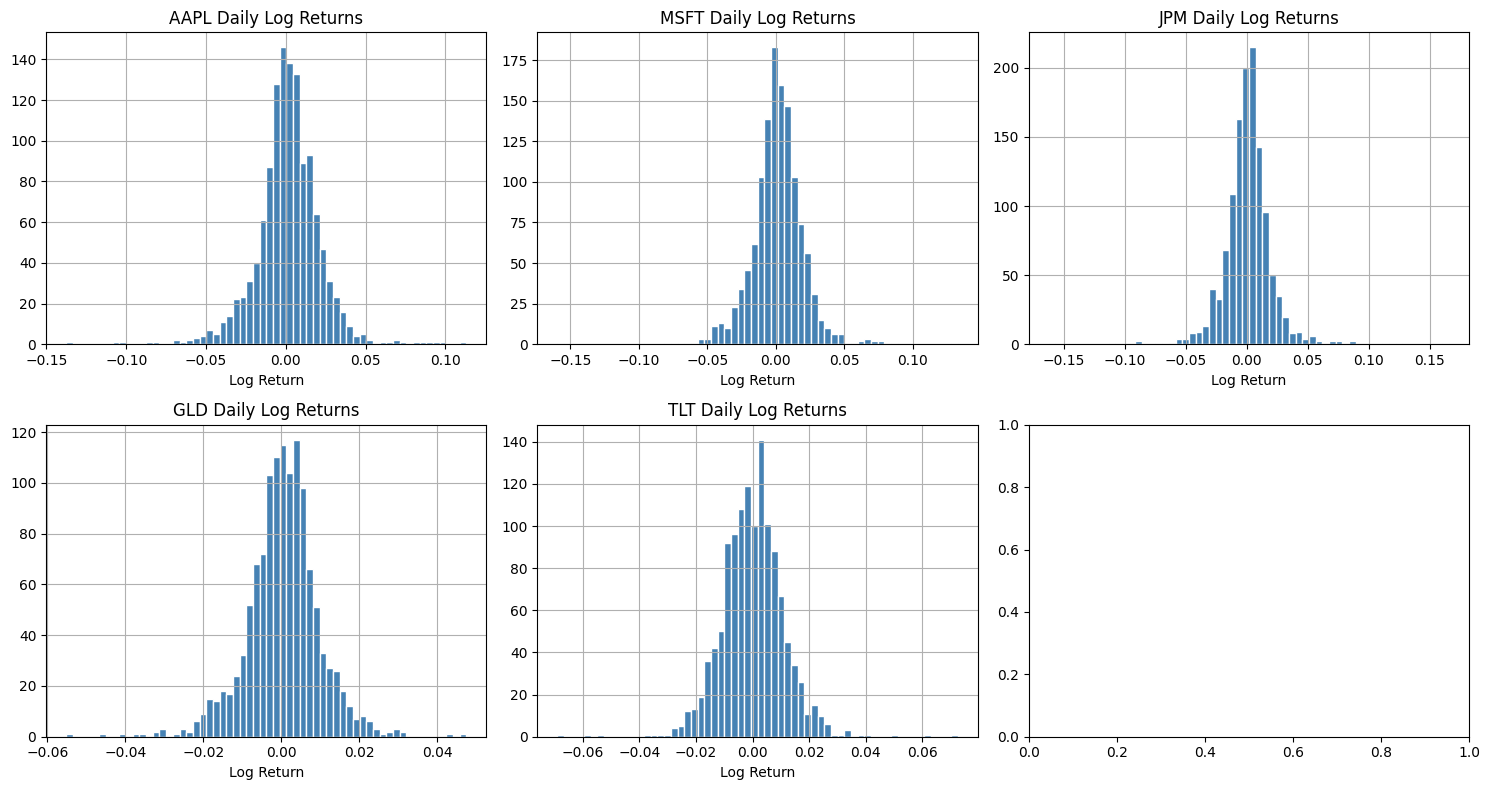

In [11]:
# Finally we visualize distribution for each asset in the portfolio

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for i, ticker in enumerate(tickers):
    ax = axes[i // 3, i % 3]
    log_returns[ticker].hist(bins=60, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{ticker} Daily Log Returns')
    ax.set_xlabel('Log Return')
plt.tight_layout()
plt.savefig('../outputs/return_distributions.png', dpi=150)  # Save the histogram plot to a file.
plt.show()